## Minimum Cover Set and Maximum possible accuracy with Top-36 transforms

In [10]:
import json
import os
import pickle
import random
from functools import partial
from glob import glob

import matplotlib
import numpy as np
import pandas as pd
import seaborn as sns
import timm
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
import torchvision.transforms.functional as fv
from matplotlib import pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from PIL import Image
from torchvision.datasets import ImageFolder
from tqdm import tqdm
import matplotlib.patches as patches

from collections import defaultdict

sns.set()

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)


### Helpers

In [11]:
dataset_names = [
    "imagenet_1k",
    "imagenet_1k_real",
    "imagenet_IN_plus_real",
    "imagenet_r",
    "imagenet_a",
    "imagenet_sketch",
    "objectnet",
]

model_names = ["resnet18", "resnet50", "vit32", "vgg16", "alexnet", "clip_vit_l_14"]

model_name_lookup = {
    "resnet18": "resnet18",
    "resnet50": "resnet50",
    "vit32": "vit_b_32",
    "vgg16": "vgg16",
    "alexnet": "alexnet",
    "clip_vit_l_14": "clip_vit_l_14"
}

pretty_model_names = {
    "resnet18": "ResNet-18",
    "resnet50": "ResNet-50",
    "vit32": "ViT-B/32",
    "vgg16": "VGG-16",
    "alexnet": "AlexNet",
    "clip_vit_l_14": "CLIP ViT-L/14"
}

pretty_dataset_names = {
    "imagenet_1k": "ImageNet",
    "imagenet_1k_real": "ImageNet ReaL",
    "imagenet_IN_plus_real": "ImageNet + ReaL",
    "imagenet_r": "ImageNet-R",
    "imagenet_a": "ImageNet-A",
    "imagenet_sketch": "ImageNet-Sketch",
    "objectnet": "ObjectNet",
}


### Load results

In [12]:
with open('../data/correctness.pkl', 'rb') as f:
    correctness_dfs = pickle.load(f)

## Classification Results

1. Standard 1-crop accuracy
2. Maximum possible accuracy

In [13]:
standard_accuracy = defaultdict(dict)
max_possible_accuracy = defaultdict(dict)

for dataset in dataset_names:
    for model in model_names:
        standard_accuracy[dataset][model] = 100* correctness_dfs[dataset][model].loc['LOC:1_1_Size:256'].mean()
        max_possible_accuracy[dataset][model]  = 100*np.mean(correctness_dfs[dataset][model].max(0))

In [14]:
s_acc_df = pd.DataFrame(standard_accuracy)
s_acc_df.index = [pretty_model_names[i] for i in s_acc_df.index]
s_acc_df.columns = [pretty_dataset_names[i] for i in s_acc_df.columns]
s_acc_df.round(2)

,ImageNet,ImageNet ReaL,ImageNet + ReaL,ImageNet-R,ImageNet-A,ImageNet-Sketch,ObjectNet
ResNet-18,69.45,76.94,76.47,32.14,1.37,19.41,27.59
ResNet-50,75.75,82.63,82.97,35.39,0.21,22.91,36.18
ViT-B/32,75.75,81.89,82.59,41.29,9.64,26.83,30.89
VGG-16,71.37,78.90,78.52,26.98,2.69,16.78,28.32
AlexNet,56.16,62.67,61.76,21.10,1.75,10.05,14.23
CLIP ViT-L/14,75.04,80.69,81.95,86.83,71.28,58.23,66.32


In [15]:
m_acc_df = pd.DataFrame(max_possible_accuracy)
m_acc_df.index = [pretty_model_names[i] for i in m_acc_df.index]
m_acc_df.columns = [pretty_dataset_names[i] for i in m_acc_df.columns]
m_acc_df.round(2)

,ImageNet,ImageNet ReaL,ImageNet + ReaL,ImageNet-R,ImageNet-A,ImageNet-Sketch,ObjectNet
ResNet-18,95.15,97.76,97.55,66.89,58.87,43.68,71.44
ResNet-50,96.78,98.62,98.57,68.84,66.68,47.64,76.83
ViT-B/32,97.19,98.75,98.91,75.58,78.03,55.99,79.28
VGG-16,95.30,97.90,97.66,60.88,58.27,39.90,71.85
AlexNet,90.03,93.85,93.48,55.52,42.23,29.53,59.65
CLIP ViT-L/14,96.78,98.70,98.80,99.20,98.49,89.00,93.13


## Min-Cover

In [16]:
def set_cover(subsets):
    elements = set(e for s in subsets.values() for e in s)
    covered = set()
    cover = []
    while covered != elements:
        key_, value_ = max(subsets.items(), key=lambda x: len(set(x[1]) - covered))
        cover.append(key_)
        covered |= set(value_)

    return cover

In [17]:
def get_min_cover(dataset, model):
    graph = {}
    min_cover = {}

    v = correctness_dfs[dataset][model]
    backup_graph = defaultdict(list)
    nodes_a = list(v.index)

    for n1 in tqdm(nodes_a, total=len(nodes_a)):
        backup_graph[n1].extend(list(v.loc[n1][v.loc[n1]].index))

    graph[model] = backup_graph

    for k, v in tqdm(graph.items(), total=len(graph)):
        S = [set(x) for x in list(v.values())]
        min_cover[k] = set_cover(v)

    return list(min_cover.values())

In [18]:
min_covers = defaultdict(dict)

for dataset in dataset_names:
    for model in model_names:
        min_covers[dataset][model] = get_min_cover(dataset, model)

100%|██████████| 1/1 [00:11<00:00, 11.94s/it]


In [19]:
# dump min covers to file

with open('../data/min_covers.pkl', 'wb') as f:
    pickle.dump(min_covers, f)

### Min Cover Size

In [20]:
min_cover_counts = defaultdict(dict)

for dataset in dataset_names:
    for model in model_names:
        min_cover_counts[dataset][model] = len(min_covers[dataset][model][0])

In [21]:
mean_cover_size_df = pd.DataFrame(min_cover_counts)
mean_cover_size_df.index = [pretty_model_names[i] for i in mean_cover_size_df.index]
mean_cover_size_df.columns = [pretty_dataset_names[i] for i in mean_cover_size_df.columns]
mean_cover_size_df['Mu'] = mean_cover_size_df.mean(1).round()
mean_cover_size_df

,ImageNet,ImageNet ReaL,ImageNet + ReaL,ImageNet-R,ImageNet-A,ImageNet-Sketch,ObjectNet,Mu
ResNet-18,250,201,208,278,211,269,254,239.0
ResNet-50,234,178,183,271,214,281,259,231.0
ViT-B/32,233,168,173,257,193,273,273,224.0
VGG-16,242,201,201,289,222,273,259,241.0
AlexNet,255,239,246,272,212,275,268,252.0
CLIP ViT-L/14,251,197,186,114,93,280,212,190.0


## Top `36` performing transformations

In [22]:
top_36_accyracy = {}

for dataset in dataset_names:
    top_36_accyracy[dataset] = {}
    for model in model_names:
        top_36 = min_covers[dataset][model][0][:36]
        results = correctness_dfs[dataset][model]
        acc = 100*results.loc[top_36].max(0).mean()
        top_36_accyracy[dataset][model] = acc

In [23]:
top_36_max_acc_df = pd.DataFrame(top_36_accyracy)
top_36_max_acc_df.index = [pretty_model_names[i] for i in top_36_max_acc_df.index]
top_36_max_acc_df.columns = [pretty_dataset_names[i] for i in top_36_max_acc_df.columns]
top_36_max_acc_df.round(2)

,ImageNet,ImageNet ReaL,ImageNet + ReaL,ImageNet-R,ImageNet-A,ImageNet-Sketch,ObjectNet
ResNet-18,92.08,95.97,95.73,58.85,47.48,37.91,63.08
ResNet-50,94.46,97.36,97.40,61.42,55.68,41.71,69.60
ViT-B/32,95.05,97.61,97.88,68.77,68.43,49.10,70.30
VGG-16,92.30,96.08,95.81,52.86,46.69,34.34,62.94
AlexNet,85.19,90.30,89.74,47.04,31.37,24.40,49.17
CLIP ViT-L/14,94.19,97.32,97.56,98.60,97.16,83.77,89.59


## Visualiztion

In [24]:
def crop_at(size, slice_x, slice_y):
    def slice_crop(image, size, slice_x, slice_y):
        new_height, new_width = size, size
        width, height = image.size

        tile_size_x = width // 3
        tile_size_y = height // 3

        anchor_x = (slice_y * tile_size_x) + (tile_size_x // 2)
        anchor_y = (slice_x * tile_size_y) + (tile_size_y // 2)

        return fv.crop(
            image,
            anchor_y - (new_height // 2),
            anchor_x - (new_width // 2),
            new_height,
            new_width,
        )

    return partial(slice_crop, size=size, slice_x=slice_x, slice_y=slice_y)

def string_to_crop(text):
    size = int(text.split('Size:')[-1])
    slice_x, slice_y = text.split('LOC:')[-1].split('_')[:2]
    
    ft = transforms.Compose([transforms.Resize(size), crop_at(size, int(slice_x), int(slice_y)), transforms.CenterCrop(224)])

    return ft
    

In [25]:
def plot_top_36_transforms(sample_image, dataset, model):
    sns.set_palette("Set2")
    sns.set_context("notebook", font_scale=1, rc={"lines.linewidth": 3})

    top36_transforms = min_covers[dataset][model][0][:36]
    
    _, axes = plt.subplots(6, 6, figsize=(30, 30))
    for i, ax in enumerate(axes.flatten()):
        ax.axis('off')
        ax.set_title(top36_transforms[i])
        ax.imshow(string_to_crop(top36_transforms[i])(sample_image))


In [27]:
sample_image = Image.open('../data/test.jpg')

In [28]:
top36_transforms = min_covers["imagenet_a"]["resnet50"][0][:36]

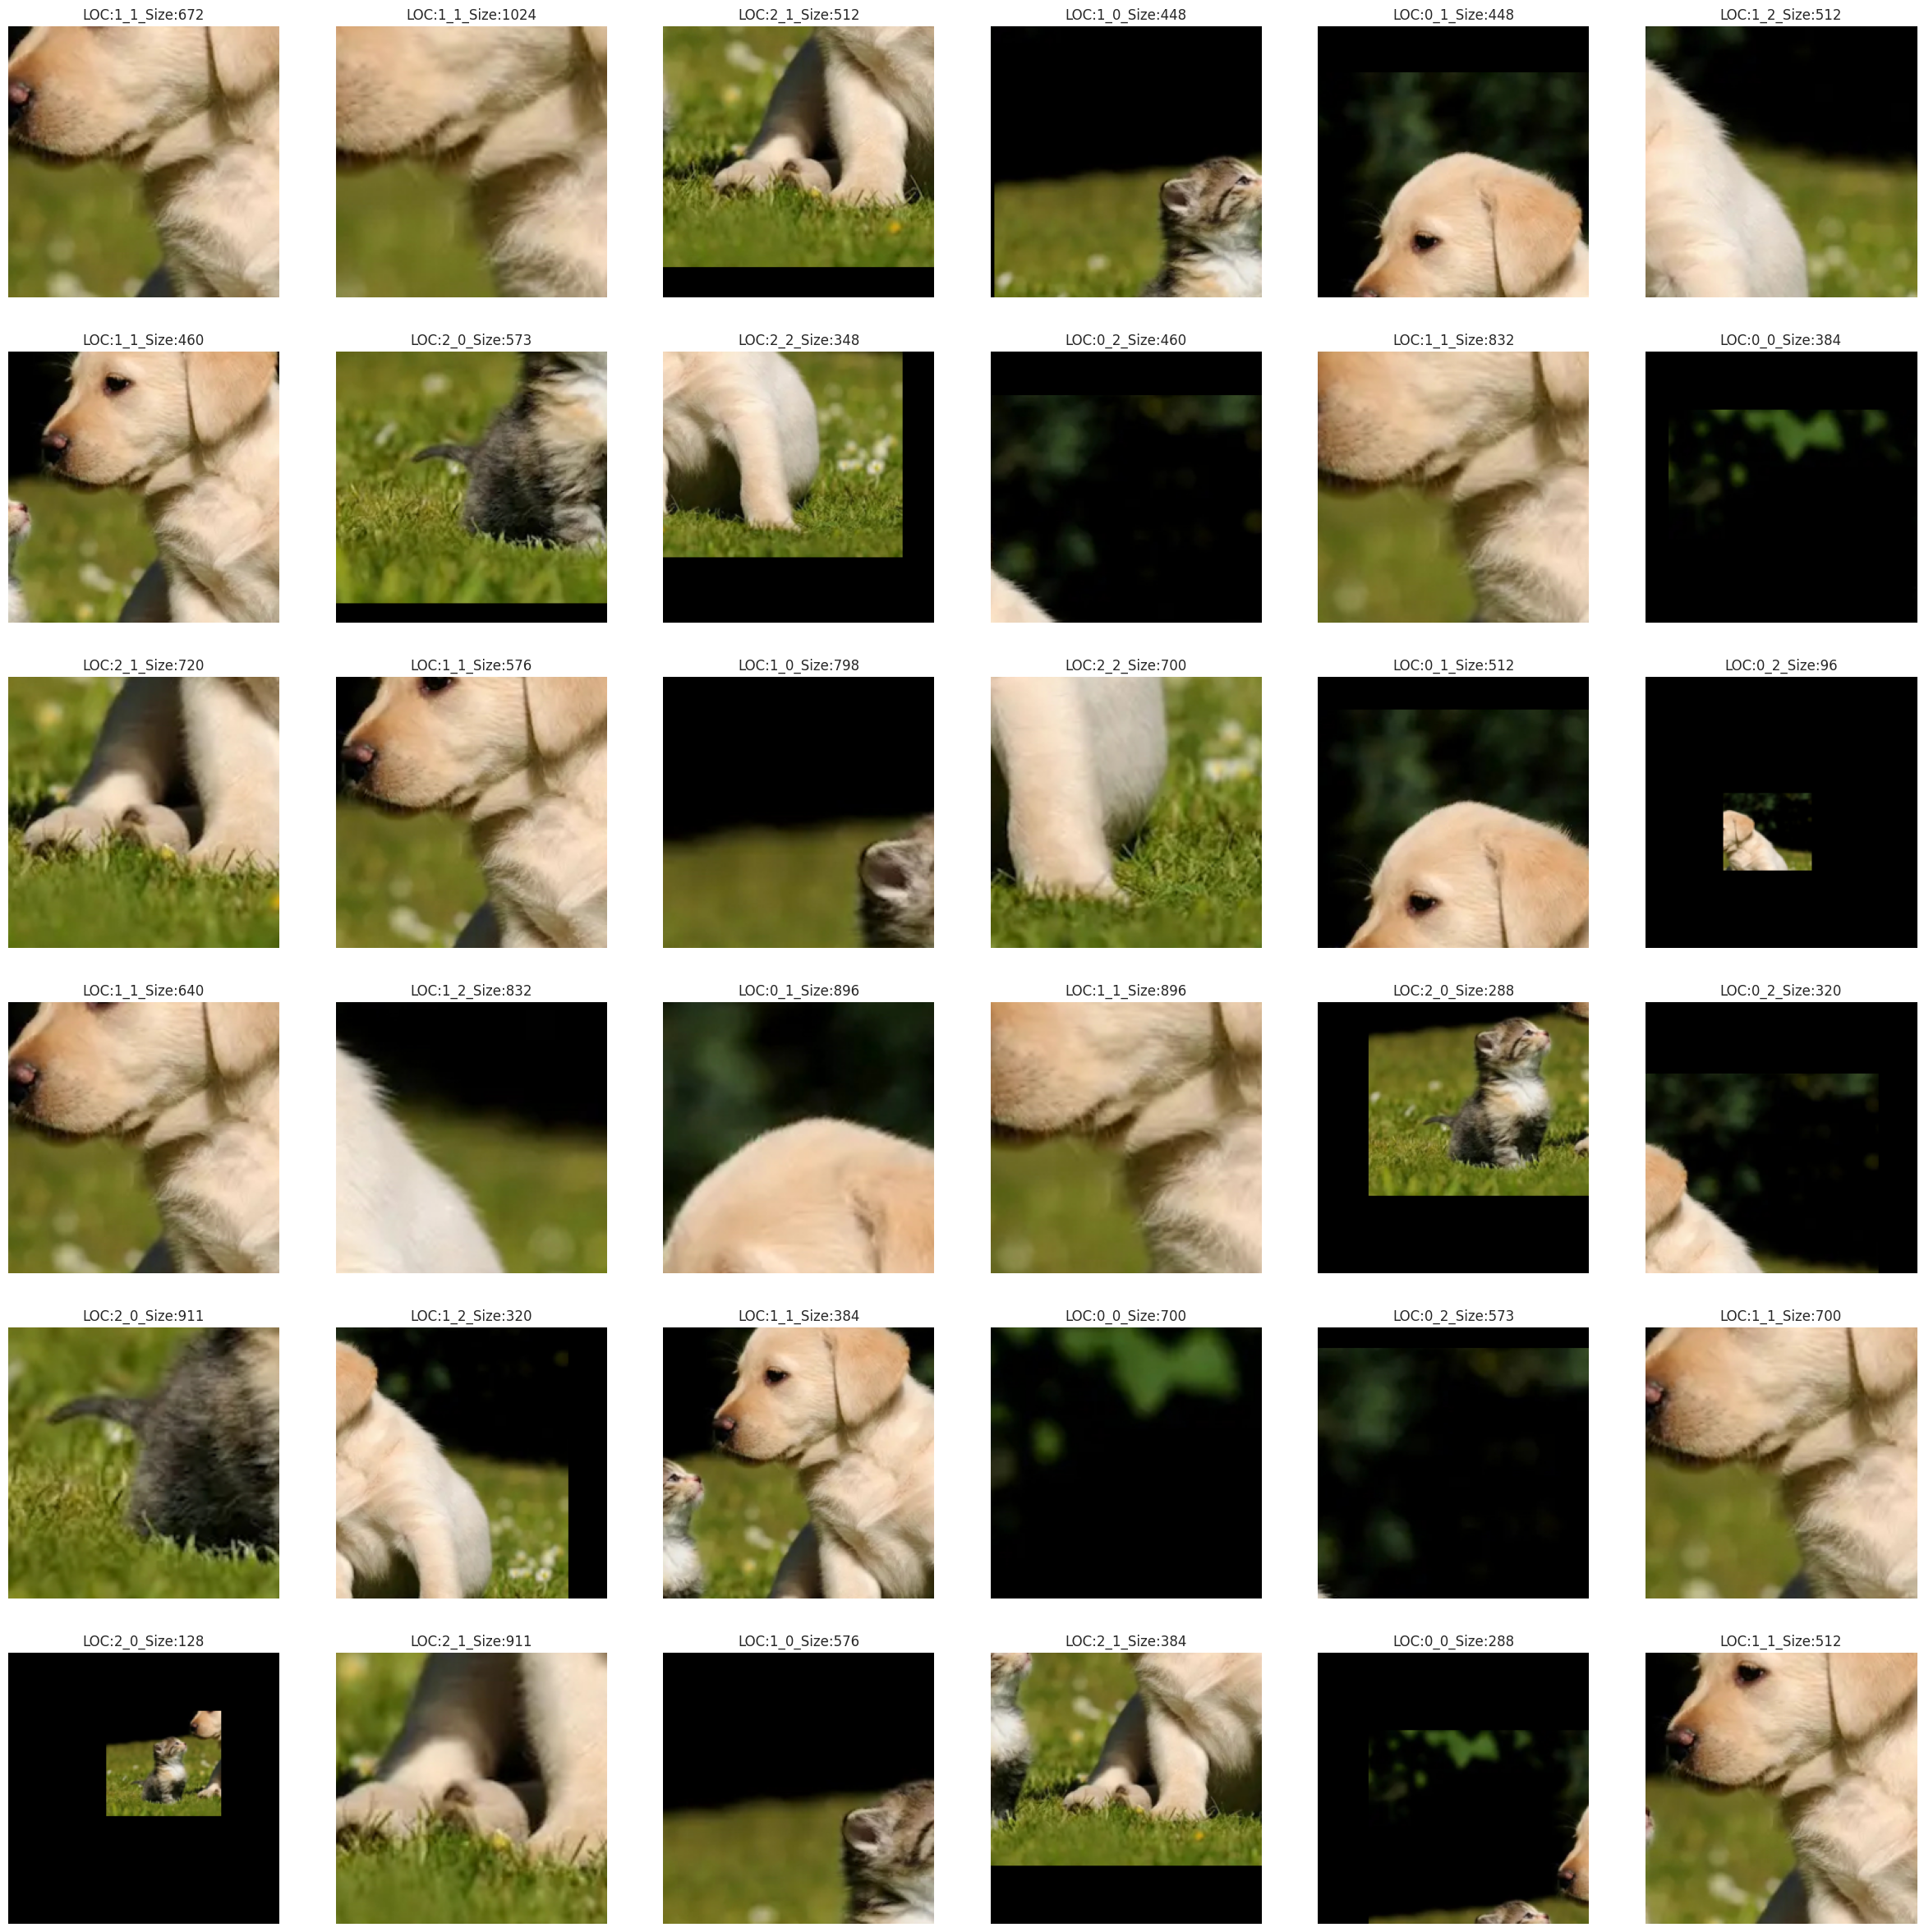

In [29]:
plot_top_36_transforms(sample_image, 'imagenet_a', 'resnet50')

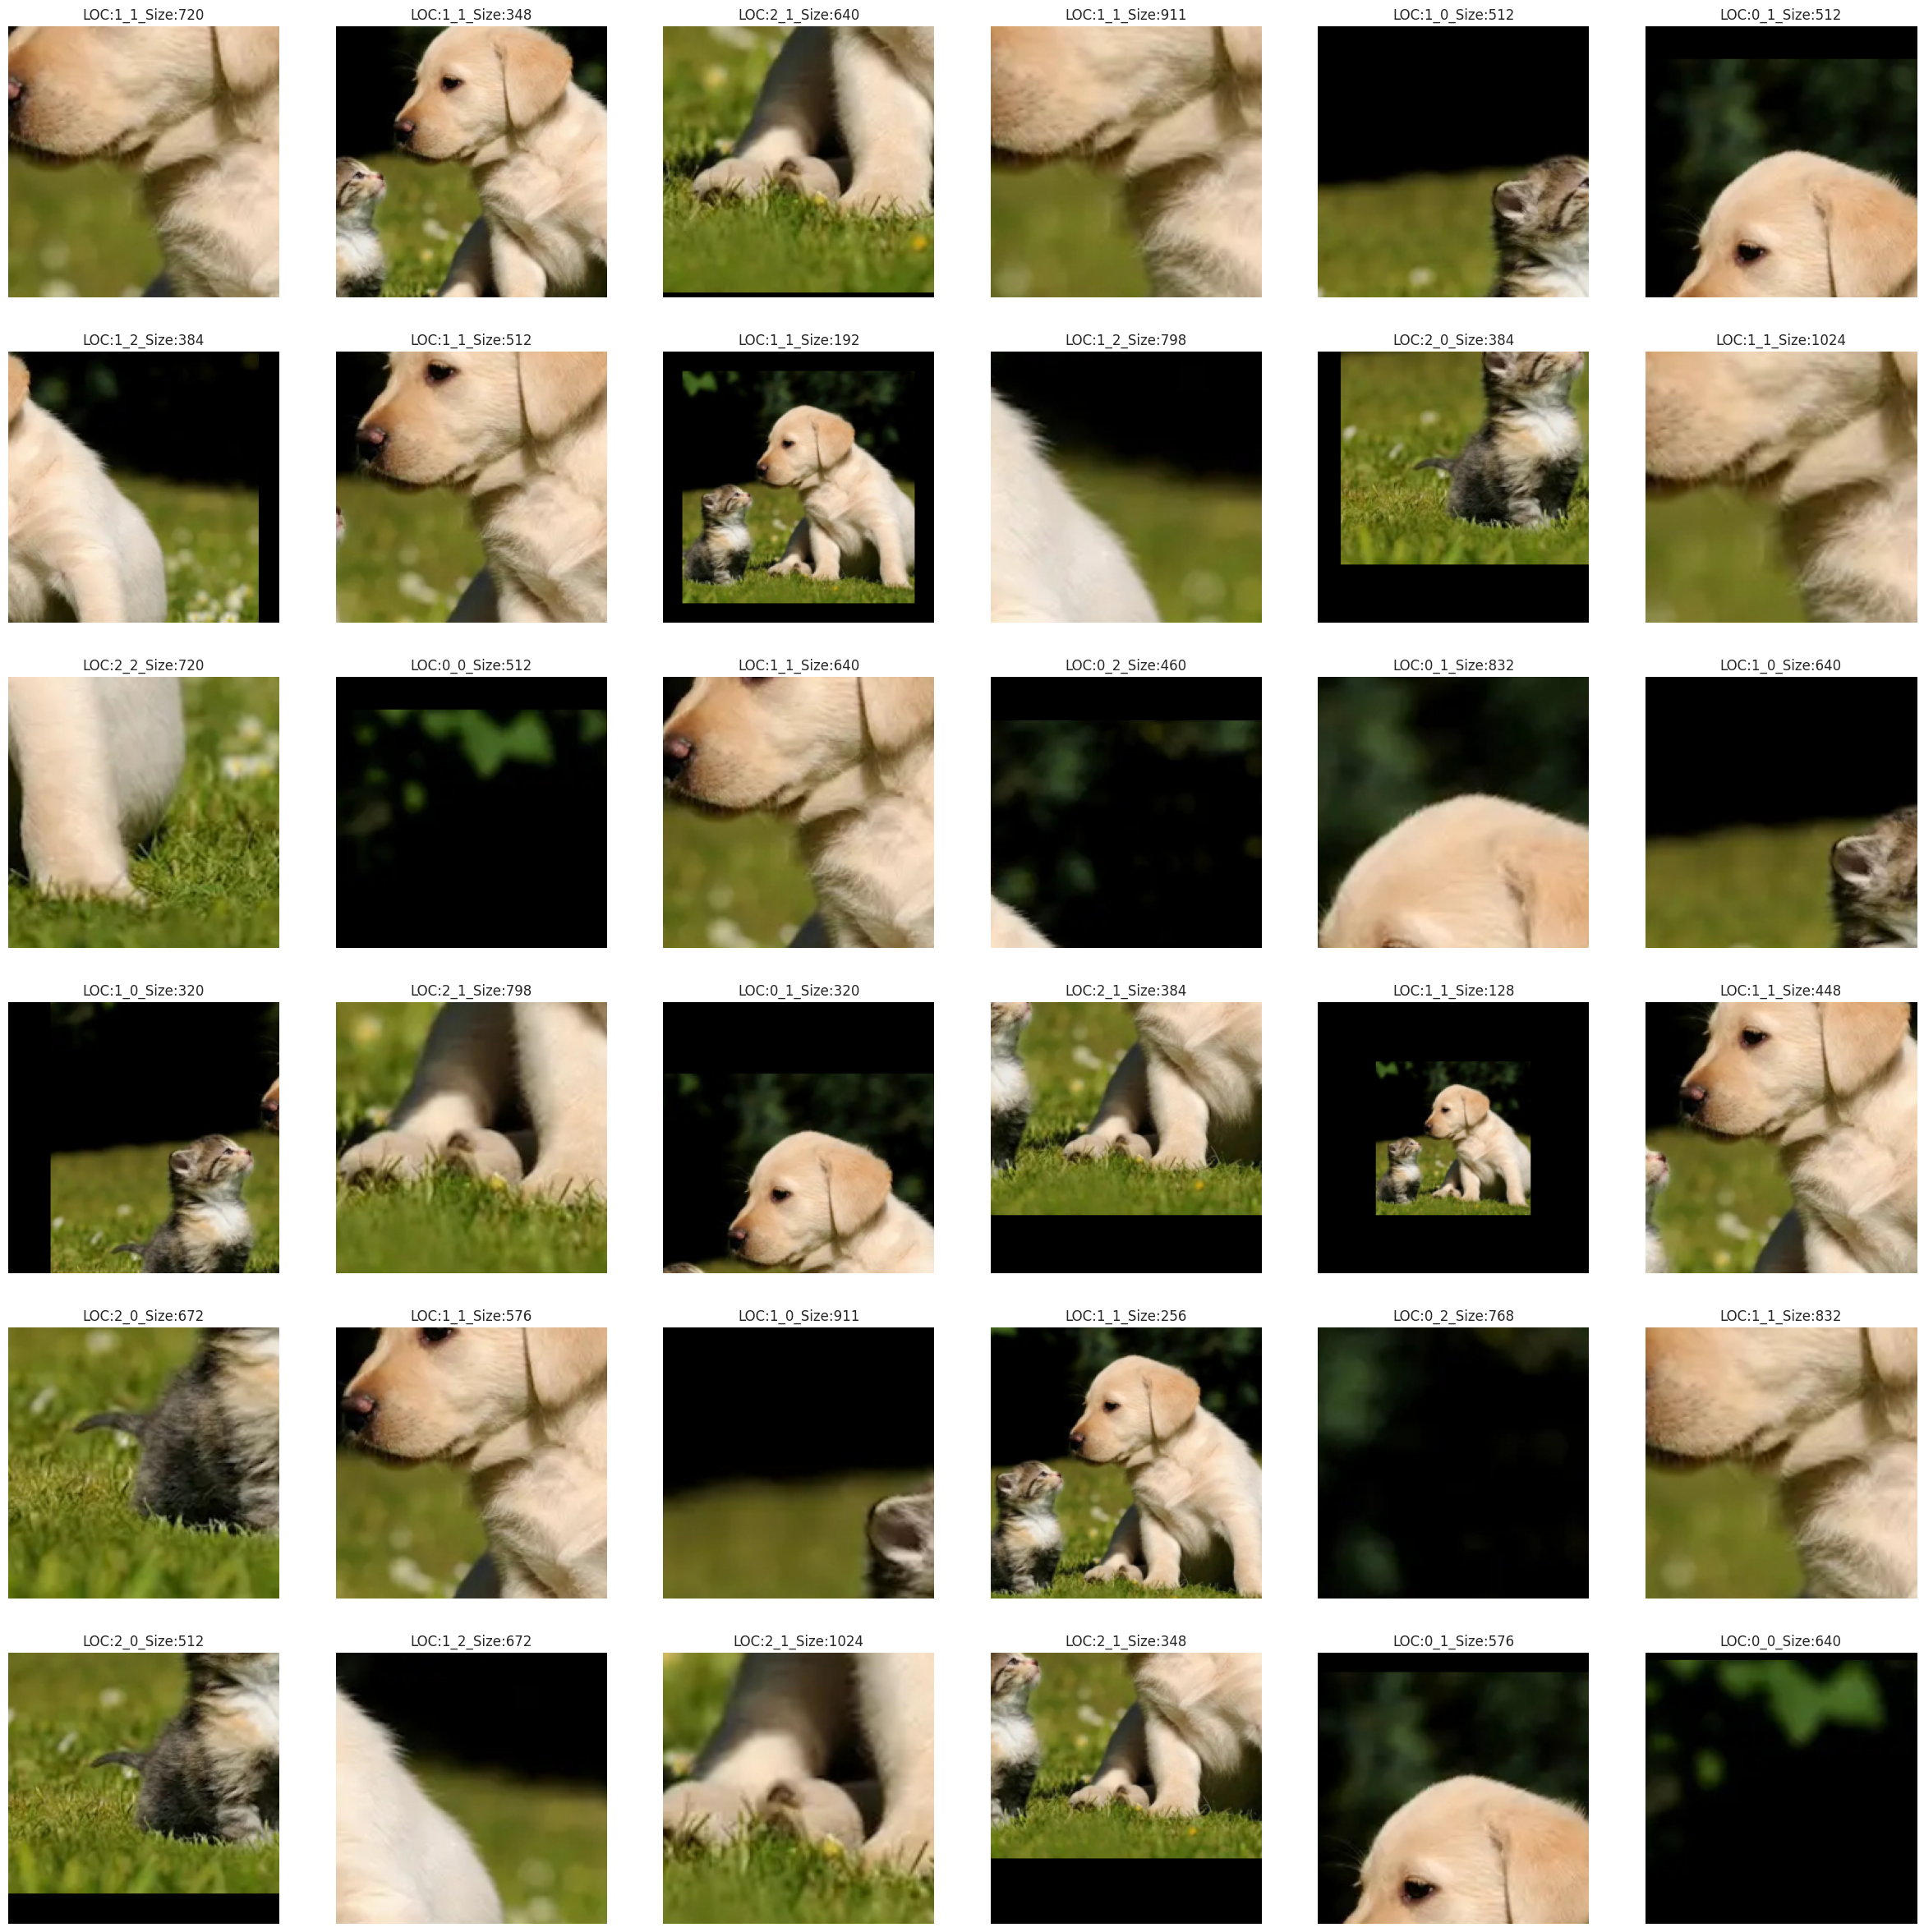

In [30]:
plot_top_36_transforms(sample_image, 'imagenet_a', 'vit32')